# Robustez, incertidumbre y monitoreo de explicaciones en XAI

Este cuaderno está pensado como un laboratorio corto para estudiar algo que a veces se pasa por alto: **no basta con producir una explicación**, también hay que preguntarse **si esa explicación es estable, si es sensible a pequeños cambios, cómo reportar su incertidumbre y qué conviene monitorear cuando el modelo ya está en uso**.

La estructura del notebook toma como punto de partida tres ideas que aparecen de manera recurrente en la literatura reciente:

1. En datos tabulares, la evaluación de explicaciones necesita criterios más claros y no debería reducirse a una sola métrica.
2. En dominios de alto impacto, como salud, la evaluación no puede ser solo técnica: también hay cuestiones de comprensión, confianza, uso real, ética y decisión de despliegue.
3. Muchos estudios aplicados todavía reportan mal sus diseños de evaluación, comparan poco entre métodos y comunican de manera insuficiente la incertidumbre o la estabilidad.

La idea aquí no es presentar una “receta definitiva”, sino dejar un ejemplo reproducible y comentado para discutir **qué medir**, **cómo interpretarlo** y **qué precauciones conviene tener**.

---

## Preguntas que van guiando el notebook

- ¿Una explicación cambia mucho si el dato cambia un poco?
- ¿Una explicación cambia mucho si el modelo se reentrena?
- ¿Cómo resumir la incertidumbre de las importancias explicativas?
- ¿Qué conviene monitorear además del desempeño predictivo?
- ¿Qué errores metodológicos conviene evitar cuando se reporta XAI?

## Referencias que orientan este notebook

- Velmurugan et al. (2025). *Developing Guidelines for Functionally-Grounded Evaluation of Explainable Artificial Intelligence using Tabular Data*.
- Amengual-Alcover et al. (2025). *Towards an Evaluation Framework for Explainable Artificial Intelligence Systems for Health and Well-being*.
- Babakov et al. (2025). *Evaluation of Explainable AI by Medical Experts: a Survey of the Existing Approaches*.

## 1. Antes de empezar: qué vamos a hacer y qué no

Voy a usar un ejemplo tabular relativamente conocido para que la atención quede puesta en la evaluación de explicaciones y no en la limpieza de datos. Eso tiene una ventaja didáctica, pero también una limitación importante: en un caso real habría que revisar con mucho más cuidado la calidad del dato, los sesgos de selección, variables proxy, representatividad, validez del outcome y riesgos de uso.

En otras palabras: este notebook es útil para **entender el esquema de evaluación**, no para concluir nada sustantivo sobre medicina o diagnóstico.

También vale la pena dejar clara una idea desde el principio:

> una explicación del modelo no es lo mismo que una explicación causal del fenómeno.

Ese recordatorio parece obvio, pero en la práctica evita varias confusiones.

In [ ]:
# Si estás en Colab, ejecuta esta celda una sola vez
!pip -q install shap scikit-learn pandas numpy matplotlib scipy

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from scipy.stats import spearmanr
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.model_selection import train_test_split

np.random.seed(42)
plt.rcParams["figure.figsize"] = (9, 5)

## 2. Cargar datos y separar entrenamiento / prueba

In [ ]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)
X.head()

Tamaño entrenamiento: (426, 30)
Tamaño prueba: (143, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Comentario metodológico

Uno de los problemas que señalan los trabajos de evaluación en XAI es que, a veces, la discusión empieza directamente por el método de explicación y deja en segundo plano el contexto del problema. En la práctica, conviene documentar desde el inicio:

- qué datos se usaron,
- qué población representan,
- cuál es la tarea de predicción,
- qué usuarios leerían las explicaciones,
- y qué decisión dependería de ellas.

Sin esa información, la evaluación de explicaciones queda flotando en el aire.

## 3. Entrenar un modelo base

Voy a usar un `RandomForestClassifier`. No porque sea “el mejor” en general, sino porque:
- es una caja negra moderada para fines didácticos,
- y se integra bien con explicaciones tipo SHAP.

La primera idea importante es simple: **si el modelo no tiene un desempeño mínimamente razonable, explicar sus predicciones no arregla el problema**.

In [ ]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=42
)
model.fit(X_train, y_train)

pred_test = model.predict(X_test)
proba_test = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, pred_test)
auc = roc_auc_score(y_test, proba_test)

print(f"Accuracy: {acc:.4f}")
print(f"AUC:      {auc:.4f}")

Accuracy: 0.9580
AUC:      0.9933


### Qué mirar aquí

No hace falta convertir esta sección en una evaluación exhaustiva de desempeño, pero sí dejar al menos dos ideas por escrito:

1. El rendimiento predictivo es una condición previa útil para que la discusión de explicaciones tenga sentido.
2. Un buen rendimiento no garantiza que las explicaciones sean útiles, fieles, estables ni apropiadas para el usuario final.

Ese segundo punto es importante porque conecta con la crítica de varios trabajos recientes: muchas veces se comunica la explicación como si fuera automáticamente confiable por el simple hecho de acompañar a un modelo con buen AUC.

## 4. Explicaciones base: una visión global y una local

Empiezo con SHAP para tener dos vistas:

- **global**: qué variables pesan más, en promedio, sobre el conjunto;
- **local**: qué variables empujan la predicción en un caso particular.

Esto no resuelve todavía ninguna pregunta sobre robustez o incertidumbre. Apenas nos da un punto de partida.

/tmp/ipykernel_3336/854508116.py:17: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_class1, X_test, show=False)


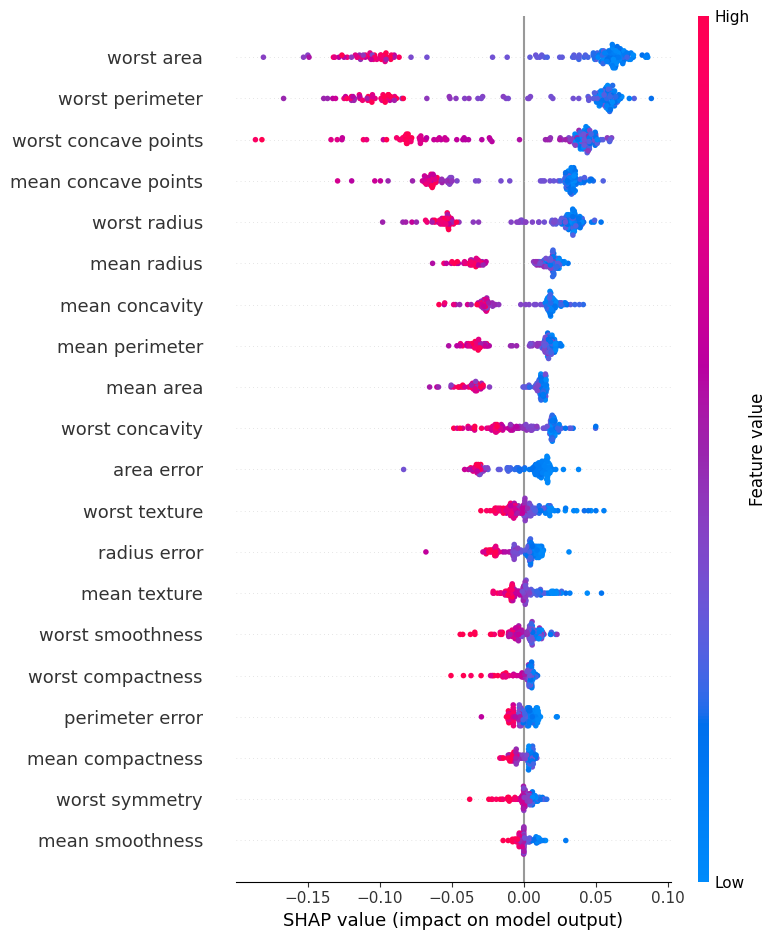

In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = extract_shap_class1(X_test)

if isinstance(shap_values, list):
    shap_class1 = shap_values[1]

elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    # (n_samples, n_features, n_classes)
    shap_class1 = shap_values[:, :, 1]

else:
    shap_class1 = shap_values

shap_df = pd.DataFrame(shap_class1, columns=X_test.columns)

# Resumen global
shap.summary_plot(shap_class1, X_test, show=False)
plt.tight_layout()
plt.show()

Clase predicha: 1
Probabilidad clase 1: 0.9915


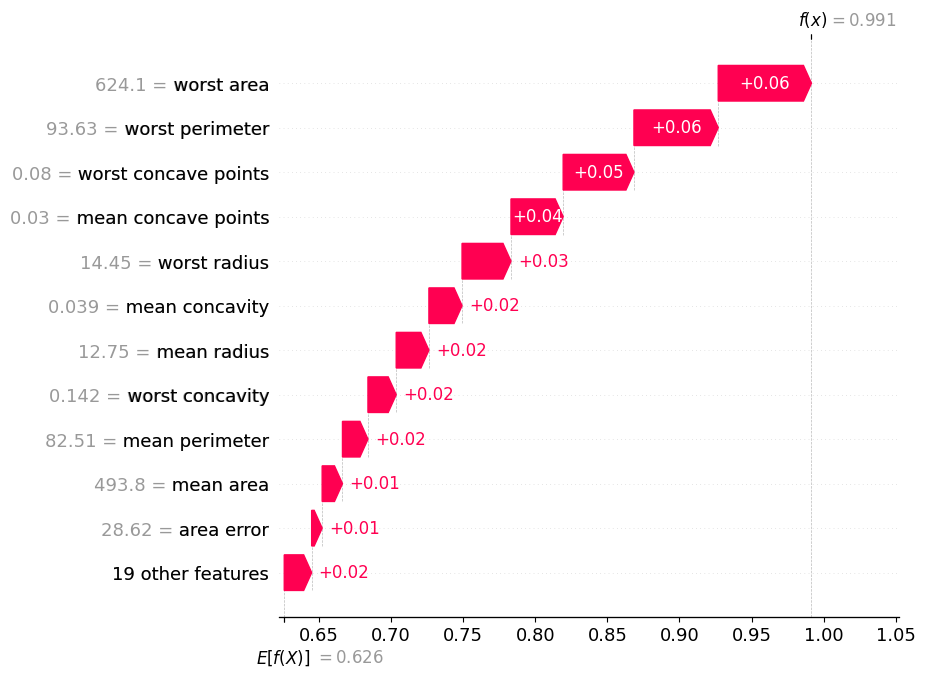

In [ ]:
# Caso individual
i = 0
x_case = X_test.iloc[[i]]

print("Clase predicha:", model.predict(x_case)[0])
print("Probabilidad clase 1:", round(model.predict_proba(x_case)[0, 1], 4))

# Construcción robusta del base value
if isinstance(explainer.expected_value, (list, np.ndarray)):
    if np.ndim(explainer.expected_value) > 0:
        base_value = explainer.expected_value[1]
    else:
        base_value = explainer.expected_value
else:
    base_value = explainer.expected_value

# Objeto Explanation para waterfall
exp = shap.Explanation(
    values=shap_class1[i],
    base_values=base_value,
    data=x_case.iloc[0].values,
    feature_names=X_test.columns.tolist()
)

shap.plots.waterfall(exp, max_display=12)

### Lectura inicial

En el análisis global, el modelo parece apoyarse principalmente en variables asociadas con tamaño e irregularidad geométrica, como worst area, worst perimeter y worst concave points. Esto sugiere una estructura explicativa relativamente coherente, en la medida en que no todas las variables contribuyen por igual y varias de las más influyentes empujan la predicción de forma consistente.

En el caso individual examinado, la probabilidad predicha para la clase 1 es muy alta (f(x) = 0.99). La explicación local sugiere que esta predicción no depende de una sola variable extrema, sino de la suma de varias contribuciones positivas, especialmente en medidas de área, perímetro, radio y puntos cóncavos. En otras palabras, el modelo parece estar acumulando evidencia en una misma dirección.

Aun así, esta lectura debe tomarse como un primer diagnóstico y no como una conclusión definitiva. En este punto todavía no sabemos si el ranking global es estable, si la explicación local resistiría pequeñas perturbaciones del input, si la narrativa cambiaría con un nuevo reentrenamiento o qué tan inciertas son las importancias observadas. Precisamente por eso, las siguientes secciones se concentran en robustez, variabilidad e implicaciones de monitoreo.
________________

Hasta aquí ya se puede conversar sobre comprensibilidad y utilidad, pero conviene no sobreactuar. A estas alturas todavía no sabemos:

- si el ranking es estable,
- si el caso individual cambiaría mucho bajo pequeñas perturbaciones,
- si otro reentrenamiento contaría una historia parecida,
- ni qué tan incierta es la importancia atribuida a cada variable.

Justamente esos vacíos son los que motivan las secciones siguientes.

## 5. Robustez local: ¿qué pasa si perturbo un poco el input?

Una crítica frecuente en la literatura es que se reportan explicaciones como si fueran objetos fijos, cuando en realidad pueden cambiar bastante si el dato cambia un poco. Para mirar eso de forma sencilla, voy a tomar una observación del conjunto de prueba y generar pequeñas perturbaciones alrededor de ella.

La idea no es hacer una simulación perfecta del dominio, sino ilustrar esta pregunta:

> si el caso cambia apenas un poco, ¿la explicación cambia de manera razonable o se desarma demasiado?

Voy a resumir la robustez con tres cosas:
- correlación de rangos entre explicación original y explicación promedio bajo perturbaciones,
- solapamiento del Top-k,
- y dispersión de los valores SHAP por variable.

In [ ]:
def local_perturbation_explanations(model, explainer, x_row, X_reference, n_perturb=100, noise_scale=0.02):
    x = x_row.copy().values.astype(float).reshape(1, -1)
    stds = X_reference.std().values

    rows = []
    for _ in range(n_perturb):
        noise = np.random.normal(0, noise_scale * stds, size=x.shape)
        rows.append((x + noise)[0])

    Xp = pd.DataFrame(rows, columns=X_reference.columns)

    sv = extract_shap_class1(Xp)

    # Compatibilidad con distintas versiones de SHAP
    if isinstance(sv, list):
        sv = sv[1]
    elif isinstance(sv, np.ndarray) and sv.ndim == 3:
        sv = sv[:, :, 1]

    return Xp, pd.DataFrame(sv, columns=X_reference.columns)


case_idx = 0
base_exp = shap_df.iloc[case_idx]

Xp, shap_pert = local_perturbation_explanations(
    model=model,
    explainer=explainer,
    x_row=X_test.iloc[case_idx],
    X_reference=X_train,
    n_perturb=120,
    noise_scale=0.02
)

In [ ]:
mean_exp = shap_pert.mean(axis=0)
std_exp = shap_pert.std(axis=0)

def top_k_features(series, k=5):
    return set(series.abs().sort_values(ascending=False).head(k).index)

rank_corr = spearmanr(base_exp.abs().rank(), mean_exp.abs().rank()).correlation
topk_base = top_k_features(base_exp, k=5)
topk_pert = top_k_features(mean_exp, k=5)
jaccard_top5 = len(topk_base & topk_pert) / len(topk_base | topk_pert)

print(f"Correlación de rangos (Spearman): {rank_corr:.4f}")
print(f"Jaccard Top-5:                    {jaccard_top5:.4f}")
print("Top-5 base:      ", topk_base)
print("Top-5 perturbado:", topk_pert)

Correlación de rangos (Spearman): 0.9964
Jaccard Top-5:                    1.0000
Top-5 base:       {'worst perimeter', 'worst radius', 'worst area', 'mean concave points', 'worst concave points'}
Top-5 perturbado: {'worst perimeter', 'worst radius', 'worst area', 'mean concave points', 'worst concave points'}


In [ ]:
robust_local = pd.DataFrame({
    "shap_base": base_exp,
    "shap_media_perturbada": mean_exp,
    "std_bajo_perturbacion": std_exp,
    "diff_abs_media_vs_base": (mean_exp - base_exp).abs()
}).sort_values("diff_abs_media_vs_base", ascending=False)

robust_local.head(10)

,shap_base,shap_media_perturbada,std_bajo_perturbacion,diff_abs_media_vs_base
worst radius,0.033930,0.029306,0.006124,0.004624
mean radius,0.022673,0.021649,0.001293,0.001024
radius error,0.002755,0.001896,0.001051,0.000859
worst perimeter,0.058435,0.057588,0.001124,0.000847
worst area,0.064631,0.063812,0.001933,0.000819
mean area,0.014082,0.013444,0.000707,0.000638
mean concave points,0.036174,0.035541,0.000653,0.000633
mean perimeter,0.017671,0.017163,0.000823,0.000507
mean symmetry,-0.002711,-0.002275,0.000753,0.000436
mean compactness,0.001157,0.000731,0.001300,0.000426


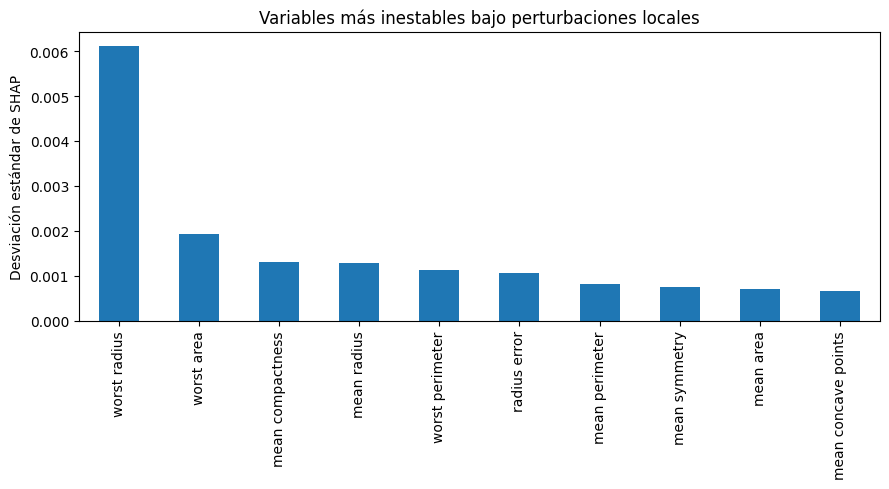

In [ ]:
robust_local["std_bajo_perturbacion"].sort_values(ascending=False).head(10).plot(kind="bar")
plt.ylabel("Desviación estándar de SHAP")
plt.title("Variables más inestables bajo perturbaciones locales")
plt.tight_layout()
plt.show()

### Cómo leer esta sección

- **Correlación de rangos alta**: el orden de importancia cambia poco.
- **Jaccard Top-5 alto**: las variables más dominantes siguen apareciendo.
- **Desviación estándar alta**: la contribución explicativa de esa variable es sensible a pequeñas perturbaciones.

Ninguna de estas medidas, por sí sola, “aprueba” o “desaprueba” la explicación. Lo interesante es el patrón conjunto.

### Conexión con los papers

El punto de fondo aquí dialoga bien con la línea de Velmurugan et al.: la evaluación funcional no debería quedarse en si la explicación “se ve razonable”, sino examinar criterios como estabilidad, sensibilidad y consistencia de una manera explícita.

### Precaución

No cualquier perturbación tiene sentido. En una aplicación real conviene definir perturbaciones plausibles para el dominio, porque una robustez calculada sobre cambios artificiales puede dar una impresión engañosa.

La explicación local para este caso es altamente robusta frente a pequeñas perturbaciones.

La correlación de rangos (0.996) indica que el orden de importancia de las variables prácticamente no cambia.
El Jaccard Top-5 = 1.0 muestra que las variables más influyentes se mantienen exactamente iguales.
Las diferencias entre la explicación original y la perturbada son muy pequeñas en magnitud.

Sin embargo, hay un matiz interesante:

worst radius presenta la mayor variabilidad (std ≈ 0.006), lo que sugiere que, aunque sigue siendo importante, su contribución es más sensible a pequeñas variaciones del input que otras variables.

## 6. Robustez entre reentrenamientos: ¿la narrativa cambia si el modelo se vuelve a entrenar?

Otra crítica frecuente es que una explicación puede depender bastante del proceso de entrenamiento: distinto `seed`, distinto muestreo, distinto fold, distinta inicialización. Si la historia explicativa cambia mucho entre modelos muy parecidos, eso debería aparecer en el reporte.

Voy a reentrenar varias veces el modelo y mirar cómo cambia la explicación del mismo caso.

In [ ]:
def extract_shap_class1(shap_values):
    if isinstance(shap_values, list):
        return shap_values[1]
    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        return shap_values[:, :, 1]
    else:
        return shap_values


def train_and_explain_one_case(random_state, X_train, y_train, X_case):
    m = RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        random_state=random_state
    )
    m.fit(X_train, y_train)

    e = shap.TreeExplainer(m)
    sv = extract_shap_class1(e.shap_values(X_case))

    return pd.Series(sv[0], index=X_case.columns)


retrain_explanations = []
for seed in [1, 7, 21, 42, 99]:
    s = train_and_explain_one_case(seed, X_train, y_train, X_test.iloc[[case_idx]])
    s.name = f"seed_{seed}"
    retrain_explanations.append(s)

retrain_df = pd.concat(retrain_explanations, axis=1)
retrain_df["media_abs"] = retrain_df.abs().mean(axis=1)
retrain_df["std_abs"] = retrain_df.abs().std(axis=1)

retrain_df.sort_values("media_abs", ascending=False).head(12)

,seed_1,seed_7,seed_21,seed_42,seed_99,media_abs,std_abs
worst area,0.048947,0.043118,0.054250,0.064631,0.065452,0.055280,0.008718
worst concave points,0.060170,0.051683,0.060382,0.049071,0.054981,0.055257,0.004506
worst perimeter,0.045718,0.055959,0.058081,0.058435,0.051025,0.053843,0.004847
worst radius,0.055046,0.045636,0.051673,0.033930,0.047808,0.046819,0.007208
mean concave points,0.033067,0.036249,0.036268,0.036174,0.039166,0.036185,0.001930
worst concavity,0.021851,0.031003,0.026705,0.019588,0.028997,0.025629,0.004293
mean concavity,0.023297,0.021409,0.017490,0.022973,0.019049,0.020844,0.002251
mean area,0.016106,0.017213,0.016911,0.014082,0.017455,0.016354,0.001223
mean radius,0.018280,0.009330,0.011698,0.022673,0.013845,0.015165,0.004772
mean perimeter,0.016172,0.016823,0.007777,0.017671,0.009414,0.013571,0.004123


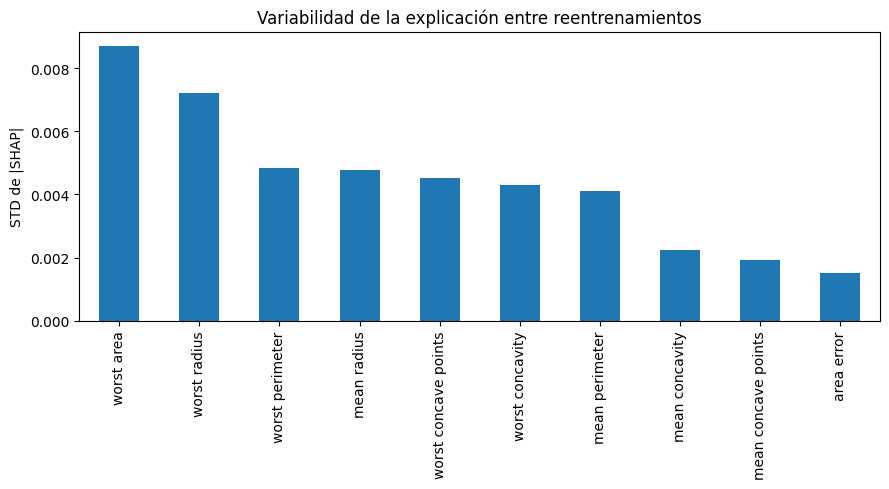

In [ ]:
retrain_df["std_abs"].sort_values(ascending=False).head(10).plot(kind="bar")
plt.ylabel("STD de |SHAP|")
plt.title("Variabilidad de la explicación entre reentrenamientos")
plt.tight_layout()
plt.show()

### Qué se gana con esta comprobación

Esta sección ayuda a separar dos cosas que a veces se mezclan:
- variabilidad propia del método de explicación,
- y variabilidad inducida por el modelo o por el proceso de entrenamiento.

Si una variable parece central en un entrenamiento y marginal en otro, no necesariamente significa que el modelo sea inútil, pero sí que la narrativa explicativa debería reportarse con más cuidado.

### Conexión con la literatura aplicada

Esto conecta con una crítica más general de los trabajos sobre evaluación en contextos sensibles: muchas veces se reporta una única ejecución y una única visualización, cuando sería más honesto mostrar cuánto cambia la historia bajo repeticiones razonables.

La explicación muestra variabilidad moderada entre reentrenamientos, pero sin cambiar la estructura principal.

Las variables más importantes (worst area, worst perimeter, worst concave points, worst radius) se mantienen consistentemente en el top, lo que indica que la narrativa general del modelo es estable.
Sin embargo, algunas de estas variables presentan variación no trivial en magnitud, especialmente:
worst area (std ≈ 0.0087)
worst radius (std ≈ 0.0072)

Esto sugiere que:

la importancia relativa es estable,
pero la intensidad de la contribución sí depende del entrenamiento específico.

## 7. Incertidumbre de explicaciones globales: bootstrap sencillo

Hasta ahora hemos visto estabilidad local y estabilidad entre reentrenamientos para un caso puntual. Ahora quiero pasar a una idea un poco más general: **la importancia global de una variable también puede tener incertidumbre**.

Para eso, hago un bootstrap sobre el conjunto de entrenamiento, reentreno el modelo varias veces y calculo la importancia global promedio con `mean(|SHAP|)` en cada repetición. Luego resumo media, desviación y algunos percentiles.

La ganancia de este paso es conceptual: en lugar de presentar un ranking rígido, empezamos a ver una banda de variación.

In [ ]:
def extract_shap_class1(shap_values):
    if isinstance(shap_values, list):
        return shap_values[1]
    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        return shap_values[:, :, 1]
    else:
        return shap_values


def bootstrap_global_shap(X_train, y_train, X_eval, n_boot=25):
    records = []

    for b in range(n_boot):
        idx = np.random.choice(len(X_train), size=len(X_train), replace=True)
        Xb = X_train.iloc[idx]
        yb = y_train.iloc[idx]

        mb = RandomForestClassifier(
            n_estimators=250,
            max_depth=6,
            random_state=100 + b
        )
        mb.fit(Xb, yb)

        eb = shap.TreeExplainer(mb)
        sv = extract_shap_class1(eb.shap_values(X_eval))

        records.append(np.abs(sv).mean(axis=0))

    return pd.DataFrame(records, columns=X_eval.columns)


boot_global = bootstrap_global_shap(X_train, y_train, X_test, n_boot=25)

uncertainty_summary = pd.DataFrame({
    "media_importancia": boot_global.mean(),
    "std_importancia": boot_global.std(),
    "p05": boot_global.quantile(0.05),
    "p95": boot_global.quantile(0.95)
}).sort_values("media_importancia", ascending=False)

uncertainty_summary.head(12)

,media_importancia,std_importancia,p05,p95
worst perimeter,0.064053,0.010435,0.046064,0.076882
worst area,0.059619,0.009817,0.046477,0.075512
worst radius,0.057099,0.009616,0.044089,0.074899
worst concave points,0.056431,0.015143,0.036860,0.079934
mean concave points,0.043133,0.008942,0.032017,0.055770
mean area,0.022986,0.005104,0.016250,0.030451
mean concavity,0.022901,0.006905,0.014096,0.035246
mean perimeter,0.022824,0.006660,0.014925,0.035598
worst concavity,0.022363,0.004515,0.017473,0.031149
mean radius,0.020536,0.005647,0.013572,0.030322


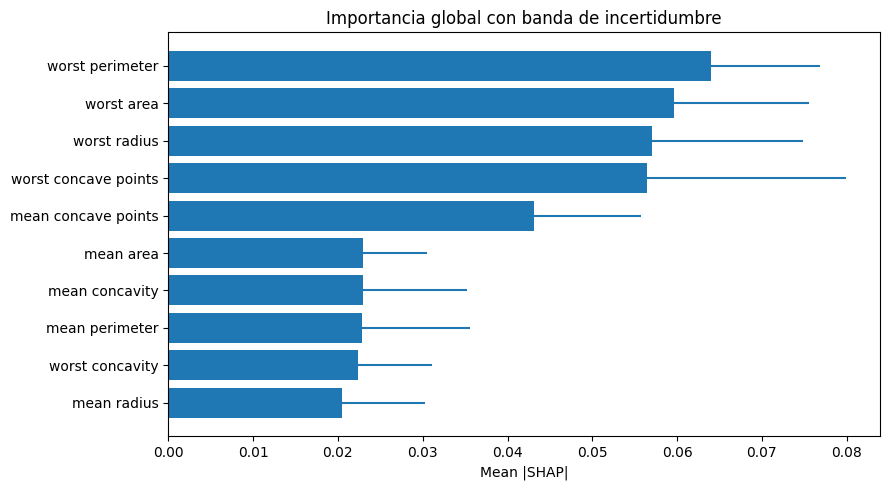

In [ ]:
topn = 10
plot_df = uncertainty_summary.head(topn).sort_values("media_importancia")

plt.barh(plot_df.index, plot_df["media_importancia"])
plt.errorbar(
    x=plot_df["media_importancia"],
    y=np.arange(len(plot_df)),
    xerr=[
        plot_df["media_importancia"] - plot_df["p05"],
        plot_df["p95"] - plot_df["media_importancia"]
    ],
    fmt="none"
)
plt.xlabel("Mean |SHAP|")
plt.title("Importancia global con banda de incertidumbre")
plt.tight_layout()
plt.show()

### Interpretación

Este gráfico ayuda a no caer en una lectura demasiado dura del ranking.

Dos variables pueden aparecer ordenadas de forma distinta en una corrida puntual y, sin embargo, tener bandas que se solapan bastante. En ese caso, sería más prudente decir algo como:

> ambas variables parecen importantes, pero su jerarquía exacta no es completamente estable.

### Por qué esto importa

Una de las críticas metodológicas que aparece en revisiones del campo es que se presentan resultados explicativos como si fueran completamente deterministas. Reportar incertidumbre no resuelve todos los problemas, pero al menos evita vender precisión donde no la hay.

## 8. Monitoreo: no solo drift de datos, también drift de explicaciones

Una vez que el modelo está en producción, normalmente se mira desempeño y a veces drift de inputs. Pero también puede ser útil revisar si la lógica explicativa aparente cambia con el tiempo.

Voy a simular un lote nuevo alterando algunas distribuciones del conjunto de prueba. No es un escenario realista en todos sus detalles, pero alcanza para mostrar la idea: comparar la importancia global explicativa antes y después.

In [ ]:
X_new = X_test.copy()
X_new["mean radius"] = X_new["mean radius"] * 1.10
X_new["mean texture"] = X_new["mean texture"] * 0.90

sv_old = extract_shap_class1(X_test)
sv_new = extract_shap_class1(X_new)

if isinstance(sv_old, list):
    sv_old = sv_old[1]
if isinstance(sv_new, list):
    sv_new = sv_new[1]

global_old = pd.Series(np.abs(sv_old).mean(axis=0), index=X_test.columns, name="old")
global_new = pd.Series(np.abs(sv_new).mean(axis=0), index=X_test.columns, name="new")

monitor_df = pd.concat([global_old, global_new], axis=1)
monitor_df["delta"] = monitor_df["new"] - monitor_df["old"]
monitor_df["pct_change"] = 100 * monitor_df["delta"] / (monitor_df["old"] + 1e-8)

monitor_df.sort_values("pct_change", ascending=False).head(12)

,old,new,delta,pct_change
mean radius,14.282469,15.710715,1.428247e+00,1.000000e+01
mean smoothness,0.097380,0.097380,6.938894e-17,7.125553e-14
fractal dimension error,0.003738,0.003738,2.168404e-18,5.800968e-14
worst symmetry,0.286697,0.286697,1.110223e-16,3.872458e-14
worst area,904.590210,904.590210,3.410605e-13,3.770332e-14
texture error,1.226179,1.226179,4.440892e-16,3.621732e-14
worst fractal dimension,0.083548,0.083548,2.775558e-17,3.322123e-14
worst texture,25.584755,25.584755,7.105427e-15,2.777211e-14
worst concave points,0.115947,0.115947,2.775558e-17,2.393806e-14
worst concavity,0.255750,0.255750,5.551115e-17,2.170522e-14


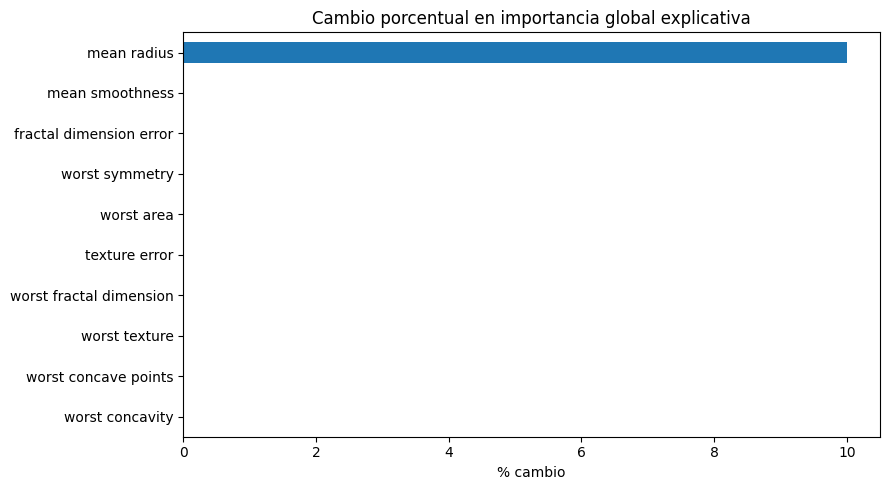

In [ ]:
monitor_df["pct_change"].sort_values().tail(10).plot(kind="barh")
plt.xlabel("% cambio")
plt.title("Cambio porcentual en importancia global explicativa")
plt.tight_layout()
plt.show()

### Qué me interesa mostrar con esto

Aun si el modelo no colapsa en desempeño, puede empezar a “mirar” el problema de una manera distinta. Esa diferencia puede importar mucho en contextos de alto impacto, porque el usuario no solo quiere una predicción, sino una justificación más o menos consistente de esa predicción.

### Relación con el enfoque aplicado de los papers

Aquí se vuelve útil la idea de Amengual-Alcover et al.: la evaluación no termina antes del despliegue. Hace falta pensar qué se revisa durante la operación del sistema, cómo se documenta y cuándo un cambio amerita auditoría o rediseño.

## 9. Un pequeño marco de lectura crítica: de la explicación al reporte

Hasta ahora hicimos estimaciones. Pero si uno se queda solo con el código, corre el riesgo de repetir una de las debilidades más señaladas en revisiones recientes: reportar poco y discutir menos.

Por eso, antes de cerrar, dejo una tabla corta con un esquema de lectura crítica.

In [ ]:
critical_frame = pd.DataFrame({
    "Dimensión": [
        "Fidelidad al modelo",
        "Robustez local",
        "Robustez entre entrenamientos",
        "Incertidumbre global",
        "Comprensibilidad",
        "Utilidad para decisión",
        "Monitoreo en operación",
        "Riesgos éticos y de uso"
    ],
    "Pregunta orientadora": [
        "¿La explicación refleja de forma razonable el comportamiento del modelo?",
        "¿Pequeñas perturbaciones cambian demasiado la explicación?",
        "¿Otro reentrenamiento cuenta una historia muy distinta?",
        "¿Qué tan estable es el ranking de importancias?",
        "¿El usuario final puede entenderla sin sobrecarga?",
        "¿La explicación ayuda a hacer una tarea concreta?",
        "¿Qué indicadores deberían revisarse periódicamente?",
        "¿La explicación puede inducir falsa confianza, sesgo o mala decisión?"
    ]
})

critical_frame

,Dimensión,Pregunta orientadora
0,Fidelidad al modelo,¿La explicación refleja de forma razonable el ...
1,Robustez local,¿Pequeñas perturbaciones cambian demasiado la ...
2,Robustez entre entrenamientos,¿Otro reentrenamiento cuenta una historia muy ...
3,Incertidumbre global,¿Qué tan estable es el ranking de importancias?
4,Comprensibilidad,¿El usuario final puede entenderla sin sobreca...
5,Utilidad para decisión,¿La explicación ayuda a hacer una tarea concreta?
6,Monitoreo en operación,¿Qué indicadores deberían revisarse periódicam...
7,Riesgos éticos y de uso,"¿La explicación puede inducir falsa confianza,..."


### Algunas buenas prácticas que conviene dejar explícitas

1. **No confundir explicación con causalidad.**
2. **No reportar una sola figura como si cerrara la discusión.**
3. **Comparar, cuando sea posible, distintos métodos o distintas corridas.**
4. **Mostrar variabilidad o incertidumbre, no solo rankings puntuales.**
5. **Explicar quién usa la explicación y para qué.**
6. **Documentar limitaciones, supuestos y posibles daños.**
7. **Monitorear la explicación después del despliegue, no solo antes.**

### Una observación importante

Varios trabajos aplicados en salud llaman la atención sobre algo muy concreto: a veces se evalúa “confianza” del usuario, pero no se distingue entre confianza bien calibrada y confianza inflada por una visualización persuasiva. Ese punto merece conversación aparte, porque una explicación bonita puede producir seguridad injustificada.